# `skipna` test

https://github.com/xCDAT/xcdat/issues/582

Enable `skipna` parameter of xarray (https://docs.xarray.dev/en/stable/generated/xarray.DataArray.mean.html) in xcdat operations

## 1. Prepare sample input data

In [1]:
import xcdat as xc
import numpy as np

In [2]:
inputfile = "/Users/lee1043/Documents/Research/git/pcmdi_metrics_20230620_pcmdi/pcmdi_metrics/doc/jupyter/Demo/demo_data/CMIP5_demo_data/ts_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc"
data_var = "ts"

In [3]:
ds = xc.open_dataset(inputfile).isel(time=slice(0, 10))

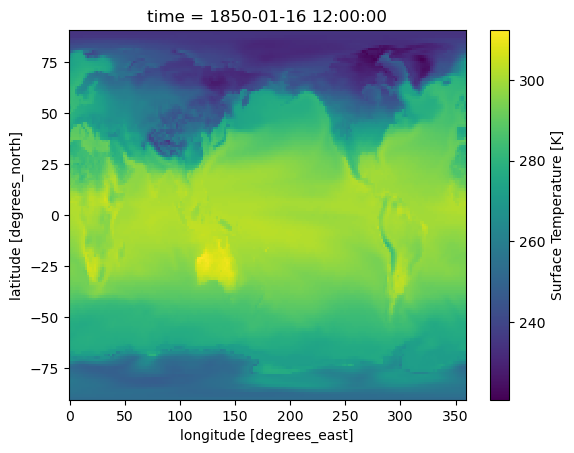

In [4]:
ds[data_var].isel(time=0).plot()

In [5]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 10, bnds: 2, lat: 145, lon: 192)
Coordinates:
  * lat        (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) object 80B 1850-01-16 12:00:00 ... 1850-10-16 12:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 160B ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    ts         (time, lat, lon) float32 1MB ...
Attributes: (12/28)
    institution:            CSIRO (Commonwealth Scientific and Industrial Res...
    institute_id:           CSIRO-BOM
    experiment_id:          historical
    source:                 ACCESS1-0 2011. Atmosphere: AGCM v1.0 (N96 grid-p...
    model_id:               ACCESS1-0
    forcing:                GHG, Oz, SA, Sl, Vl, BC, OC, (GHG = CO2, N2O, CH4...
    ...                     ...
    table_id:               Table Amon (27 April 2011) 9c851218e3842df9a62ef3...
    title:                  ACCESS1-0 model output prepared for CMIP5 historical
    parent_experiment:      pre-industrial control
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.8.0

In [6]:
ds.isel(time=0).spatial.average(data_var)[data_var].item()

285.88807821517435

### Inject NaN values in time step 0

In [7]:
da = ds[data_var].isel(time=0).copy()

# Define the latitude and longitude ranges
lat_range = (20, 70)
lon_range = (210, 320)

# Create masks for the latitude and longitude ranges
lat_mask = (da.lat >= lat_range[0]) & (da.lat <= lat_range[1])
lon_mask = (da.lon >= lon_range[0]) & (da.lon <= lon_range[1])

# Use broadcasting to apply the masks across the array dimensions
da.values[np.ix_(lat_mask, lon_mask)] = np.nan

# Update the original dataset with the modified data array
ds[data_var].values[0] = da

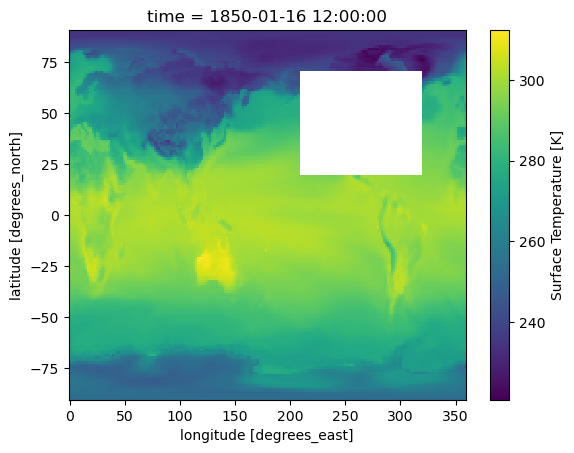

In [8]:
ds[data_var].isel(time=0).plot()

## 2. Spatial Average

### Average operation (skipping NaN by default)

In [9]:
ds.isel(time=0).spatial.average(data_var)[data_var].item()

286.89966412418875

### Average operation (skipping NaN by given option, expect the same as above)

In [10]:
ds.isel(time=0).spatial.average(data_var, skipna=True)[data_var].item()

286.89966412418875

### Average operation (non skipping NaN by given option, expect NaN)

In [11]:
ds.isel(time=0).spatial.average(data_var, skipna=False)[data_var].item()

nan

## 3. Temporal average

### Average operation (skipping NaN by default)

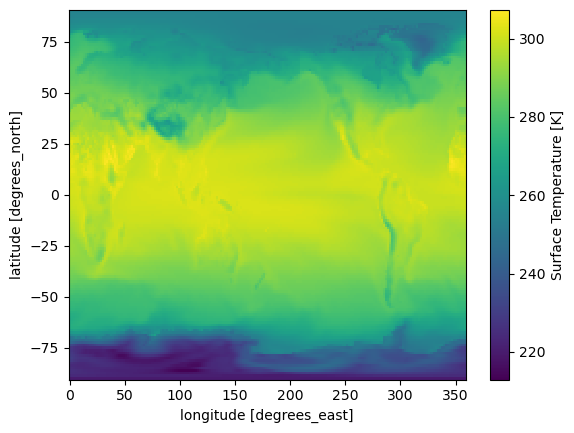

In [12]:
ds.temporal.average(data_var)[data_var].plot()

### Average operation (skipping NaN by given option, expect the same as above)

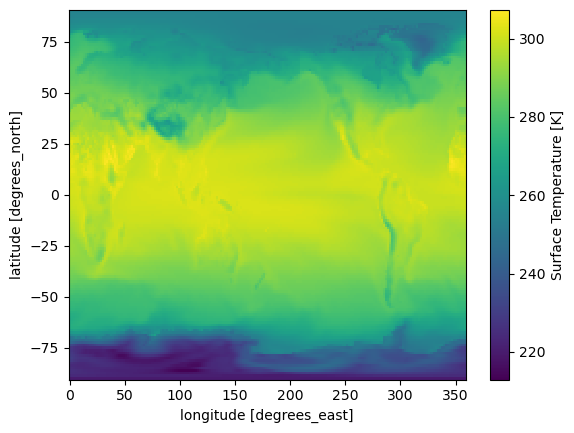

In [13]:
ds.temporal.average(data_var, skipna=True)[data_var].plot()

### Average operation (non skipping NaN by given option, expect NaN for where NaN exists)

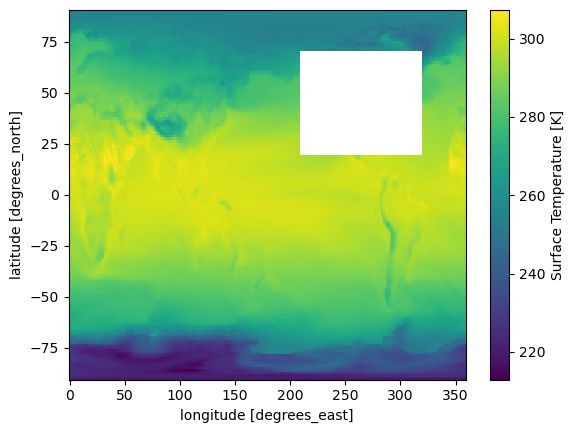

In [14]:
ds.temporal.average(data_var, skipna=False)[data_var].plot()

## Test with a real world data

In [39]:
inputfile = "/Users/lee1043/Documents/Research/git/pcmdi_metrics_20230620_pcmdi/pcmdi_metrics/doc/jupyter/Demo/demo_data/obs4MIPs_PCMDI_monthly/MOHC/HadISST-1-1/mon/ts/gn/v20210727/ts_mon_HadISST-1-1_PCMDI_gn_187001-201907.nc"
data_var = "ts"

In [40]:
#ds = xc.open_dataset(inputfile).isel(time=slice(0, 240))
ds = xc.open_dataset(inputfile)

In [ ]:
# Convert -1e30 to NaN in ds[data_var]
ds[data_var].values[ds[data_var].values == -1e30] = np.nan

In [28]:
"""
!pip install hvplot panel
!pip install jupyter_bokeh
"""

'\n!pip install hvplot panel\n!pip install jupyter_bokeh\n'

In [42]:
import hvplot.xarray  # activates hvplot method on xarray objects
import panel as pn
pn.extension()

da = ds[data_var]
da.hvplot.quadmesh('lon', 'lat', frame_width=500, cmap='viridis', 
                   clim=(da.min(), da.max()), 
                   widget_type='scrubber', widget_location='bottom')

BokehModel(combine_events=True, render_bundle={'docs_json': {'b8a7bce2-bcf5-4f8c-8ca6-7aafc927be30': {'version…

### Average

In [59]:
ds_avg = ds.temporal.average(data_var)[data_var]
ds_avg_2 = ds.temporal.average(data_var, skipna=False)[data_var]

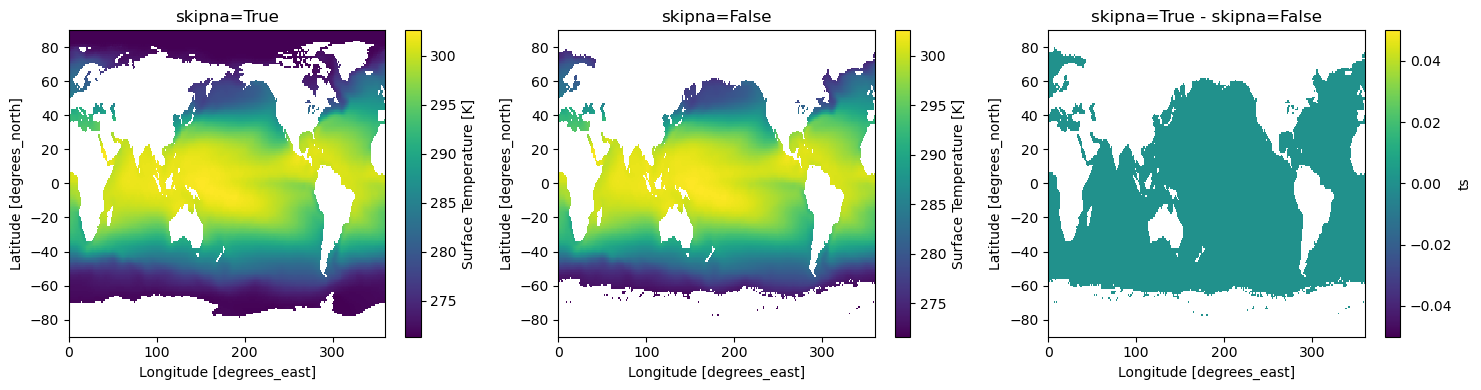

In [60]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot the first dataset
ds_avg.plot(ax=axes[0])
axes[0].set_title("skipna=True")
ds_avg_2.plot(ax=axes[1])
axes[1].set_title("skipna=False")
(ds_avg - ds_avg_2).plot(ax=axes[2])
axes[2].set_title("skipna=True - skipna=False")

fig.tight_layout()

### Climatology

In [ ]:
ds_clim_0_skipna = ds.temporal.climatology(data_var, freq="month")[data_var].isel(time=0)
ds_clim_0_nonskipna = ds.temporal.climatology(data_var, freq="month", skipna=False)[data_var].isel(time=0)

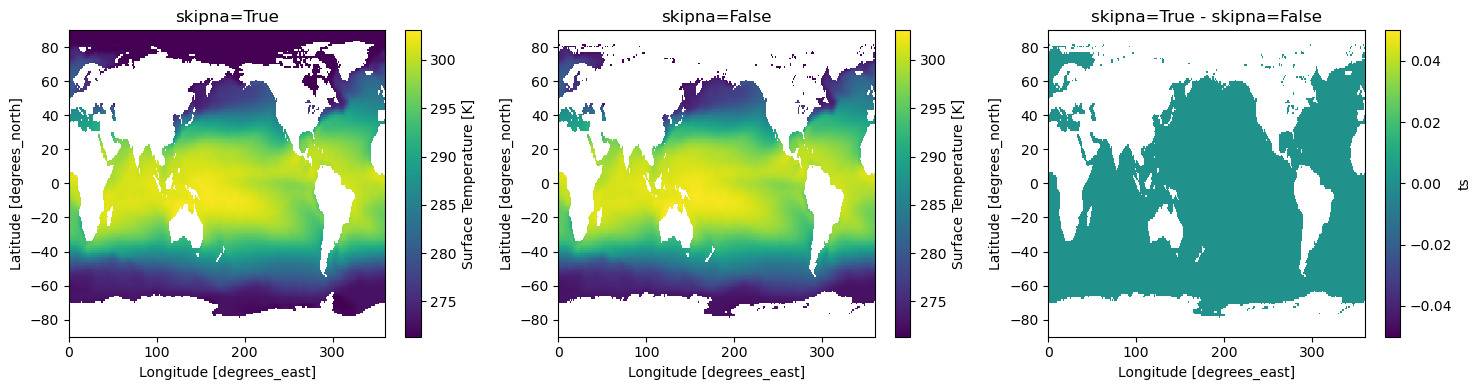

In [55]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot the first dataset
ds_clim_0_skipna.plot(ax=axes[0])
axes[0].set_title("skipna=True")
ds_clim_0_nonskipna.plot(ax=axes[1])
axes[1].set_title("skipna=False")
(ds_clim_0_skipna - ds_clim_0_nonskipna).plot(ax=axes[2])
axes[2].set_title("skipna=True - skipna=False")

fig.tight_layout()

### Departures

In [57]:
ds_departure_0_skipna = ds.temporal.departures(data_var, freq="month")[data_var].isel(time=0)
ds_departure_0_nonskipna = ds.temporal.departures(data_var, freq="month", skipna=False)[data_var].isel(time=0)

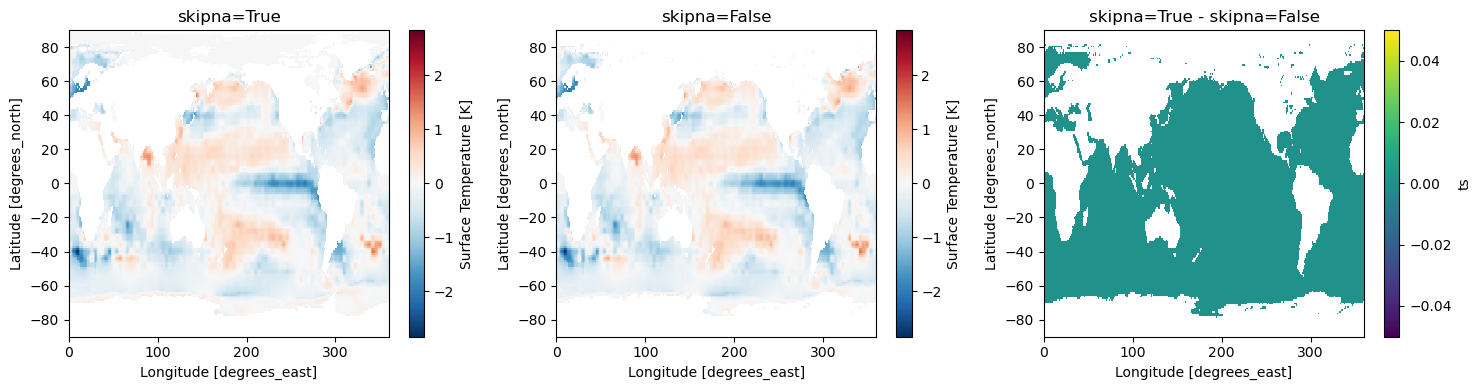

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot the first dataset
ds_departure_0_skipna.plot(ax=axes[0])
axes[0].set_title("skipna=True")
ds_departure_0_nonskipna.plot(ax=axes[1])
axes[1].set_title("skipna=False")
(ds_departure_0_skipna - ds_departure_0_nonskipna).plot(ax=axes[2])
axes[2].set_title("skipna=True - skipna=False")

fig.tight_layout()